# Random forest regressie in Python (fylogenetische diversiteit)

### Gebruikte python modules inladen

In [13]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
DATA_DIR = pathlib.Path(r"C:\Emma\2. Bestanden\1. UGent\3e bachelor (2025-2026)\2e semester\Bachelorproef\Programmeergedeelte\Bachelorproef\Data") #deze moet je dan aanpassen naar waar jouw bestand staat op je computer

### Data inladen

Data van Aquamaps (enkel de variabelen constant over de tijd)

In [14]:
df_env = pd.read_csv(DATA_DIR / "Diversity_data_with_env.csv")
df_env = df_env[["long_deg", "lat_deg", "DepthMean", "LandDist", "Shelf", "Slope", "Abyssal", "Seamount"]]
print(f"Diversity_data_with_env:             {df_env.shape}")

df_env.head()

Diversity_data_with_env:             (2452, 8)


,long_deg,lat_deg,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount
0,-171.74579,-71.23536,3998,636,0.0,730.228795,263.361205,0
1,-167.88679,-71.23536,4079,742,0.0,0.000000,993.590000,0
2,-164.02779,-71.23536,4185,708,0.0,0.000000,993.590000,0
3,-160.16879,-71.23536,4231,661,0.0,0.000000,993.590000,0
4,-156.30979,-71.23536,4322,608,0.0,0.000000,993.590000,0


Data van Bio-oracle

In [15]:
df_biooracle = pd.read_csv(DATA_DIR/"Diversity_data_with_biooracle_2010.csv")

print(f"Diversity_data_with_biooracle_2010:             {df_env.shape}")

df_biooracle.head()

Diversity_data_with_biooracle_2010:             (2452, 8)


,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,chl_max,chl_mean,chl_min,clt_max,clt_mean,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,44,11.830844,0.007171,-171.74579,-71.23536,1.987486,0.264222,0.015311,0.993542,0.681597,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,43,11.830844,0.007171,-167.88679,-71.23536,2.205368,0.278952,0.015232,0.961121,0.693978,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,44,12.650381,0.007499,-164.02779,-71.23536,1.891105,0.270836,0.015052,0.960210,0.698352,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,44,12.650381,0.007499,-160.16879,-71.23536,1.963815,0.293940,0.015424,0.962838,0.693123,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,45,12.650381,0.007499,-156.30979,-71.23536,1.956123,0.298378,0.015726,0.969080,0.688964,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


### Variabelen bekijken

In [16]:
df_biooracle.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

In [17]:
df_env.columns

Index(['long_deg', 'lat_deg', 'DepthMean', 'LandDist', 'Shelf', 'Slope',
       'Abyssal', 'Seamount'],
      dtype='object')

### Beide datasets samenvoegen obv de locatie (latitude en longitude)

In [18]:
df_merge = pd.merge(df_env, df_biooracle, on = ["long_deg", "lat_deg"], how = "inner")

print(f"d:             {df_merge.shape}")

df_merge.head()

d:             (2452, 81)


,long_deg,lat_deg,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount,marine_species_richness,PD,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,-171.74579,-71.23536,3998,636,0.0,730.228795,263.361205,0,44,11.830844,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,-167.88679,-71.23536,4079,742,0.0,0.000000,993.590000,0,43,11.830844,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,-164.02779,-71.23536,4185,708,0.0,0.000000,993.590000,0,44,12.650381,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,-160.16879,-71.23536,4231,661,0.0,0.000000,993.590000,0,44,12.650381,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,-156.30979,-71.23536,4322,608,0.0,0.000000,993.590000,0,45,12.650381,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


### Categorische variabele encoderen als numerieke variabele

Geen categorische variabelen aanwezig

In [19]:
df_merge.select_dtypes(include = ["category", "object"])

""
0
1
2
3
4
...
2447
2448
2449
2450


Overbodige variabelen verwijderen (aantal variabelen beperken)

de 2 andere biodiversiteitsmaten eruit laten, zodat het model zich niet daarop baseert, enkel gemiddeldes aangezien die de meeste info geven (max, min en range dus laten wegvallen)

In [20]:
cols_to_drop = (df_merge.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["marine_species_richness", "co1_genetic_diversity_mean"])
df_merge = df_merge.drop(cols_to_drop, axis = 1)

### Dubbele kolommen verwijderen

In [21]:
df_merge = df_merge.T.drop_duplicates().T

df_merge.head()

,long_deg,lat_deg,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount,PD,chl_mean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,-171.74579,-71.23536,3998.0,636.0,0.0,730.228795,263.361205,0.0,11.830844,0.264222,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,-167.88679,-71.23536,4079.0,742.0,0.0,0.000000,993.590000,0.0,11.830844,0.278952,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,-164.02779,-71.23536,4185.0,708.0,0.0,0.000000,993.590000,0.0,12.650381,0.270836,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,-160.16879,-71.23536,4231.0,661.0,0.0,0.000000,993.590000,0.0,12.650381,0.293940,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,-156.30979,-71.23536,4322.0,608.0,0.0,0.000000,993.590000,0.0,12.650381,0.298378,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


In [22]:
df_merge.columns

Index(['long_deg', 'lat_deg', 'DepthMean', 'LandDist', 'Shelf', 'Slope',
       'Abyssal', 'Seamount', 'PD', 'chl_mean', 'clt_mean',
       'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

### Data exploratie

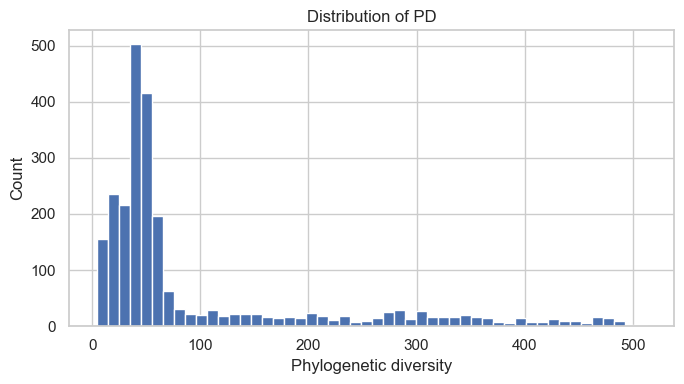

In [24]:
# histogram van de gekozen biodiversiteitsmaat
target = "PD"
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_merge[target], bins=50, edgecolor="white")
ax.set_xlabel("Phylogenetic diversity")
ax.set_ylabel("Count")
ax.set_title("Distribution of PD")
plt.tight_layout()
plt.show()

#### correlatie berekenen van alle variabelen tov target en sorteren van hoog naar laag

In [25]:
corr_to_target = df_merge.corr(method = "pearson")[target].drop(labels = [target]) #correlatie berekenen van alle variabelen tov target en correlatie target met zichzelf laten vallen (is toch gelijk aan 1)
top = corr_to_target.reindex(corr_to_target.abs().sort_values(ascending=False).index) #sorteer van hoog naar laag
top.head(15)


clt_mean       -0.595241
T_mean          0.518716
tas_mean        0.506403
o2_mean        -0.494494
po4_mean       -0.447619
no3_mean       -0.407352
par_mean        0.357730
LandDist       -0.337743
mlotst_mean    -0.323380
si_mean        -0.280319
long_deg        0.275078
dfe_mean        0.274611
siconc_mean    -0.241509
sithick_mean   -0.229886
chl_mean       -0.227759
Name: PD, dtype: float64

### Target en variabelen selecteren

In [26]:
feature_cols = df_merge.columns.drop(["long_deg", "lat_deg", target]).tolist()

print(feature_cols) #dit zijn de variabelen waarop we ons model gaan baseren

['DepthMean', 'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Seamount', 'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean', 'terrain_characteristics_rug', 'terrain_characteristics_slope', 'terrain_characteristics_topo', 'T_mean']


In [27]:
df_model = df_merge[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df_model.shape}")
df_model.head()

Shape before cleaning: (2452, 31)


,PD,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount,chl_mean,clt_mean,currentdirection_mean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,11.830844,3998.0,636.0,0.0,730.228795,263.361205,0.0,0.264222,0.681597,262.594180,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,11.830844,4079.0,742.0,0.0,0.000000,993.590000,0.0,0.278952,0.693978,253.701709,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,12.650381,4185.0,708.0,0.0,0.000000,993.590000,0.0,0.270836,0.698352,218.128087,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,12.650381,4231.0,661.0,0.0,0.000000,993.590000,0.0,0.293940,0.693123,227.064190,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,12.650381,4322.0,608.0,0.0,0.000000,993.590000,0.0,0.298378,0.688964,240.243384,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


Ontbrekende waarden verwijderen

In [28]:
# Ontbrekende waarden worden als -9999 aangegeven in de dataset.
df_model.replace(-9999.0, np.nan, inplace=True)
df_model.replace(-9999, np.nan, inplace=True)

missing = df_model.isna().sum() # Ontbrekende waarden tellen.
print("Missing values per column:\n")
print(missing[missing > 0])

df_model.dropna(inplace=True) # Ontbrekende waarden verwijderen.
print(f"\nShape after dropping rows with NaN: {df_merge.shape}")

Missing values per column:

chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean                             235
tas_mean                            235
terrain_characteristics_aspect      235
terrain_characteristics_bea_mean    235
terrain_characteristics_rug         235
terrain_characteristics_slope       235
terrain_characteristics_topo        235
T_mean                              235
dtype: int64

### Willekeurig splitten van de data in een training set en een test set

In [29]:
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 1760
Test samples:     441


### Fitten van een Random Forest model op de training dataset

De hyperparameters mogen aangepast worden

In [32]:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=30,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Hyperparameters optimaliseren

In [ ]:
#from sklearn.model_selection import GridSearchCV
#from sklearn.ensemble import RandomForestRegressor

#rf = RandomForestRegressor(random_state=42)

 #de hyperparameters optimaliseren 
#param_grid = {
    #"n_estimators": [200, 500, 800],
    #"max_depth": [10, 20, 30, None],
    #"min_samples_leaf": [1, 5, 10],
    #"max_features": ["sqrt", 0.3, 0.5]
#}

#grid = GridSearchCV(
    #rf,
    #param_grid,
    #cv=5,
    #scoring="r2",
    #n_jobs=-1
#)

#grid.fit(X_train, y_train)

#print(grid.best_params_)

{'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 800}


Deze hyperparameters gebruiken in random forest model

{'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 800}

### Evalueren van ons Random Forest model op de training set en de test set
Moet op beide goed zijn anders is het overgefit op training set

In [ ]:
# voorspellingen maken op de test set
y_pred = rf.predict(X_test)

# Evalueren van een aantal metrieken
r2_train = rf.score(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train R² : {r2_train:.4f}")
print(f"Test  R² : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"\nTrain–test gap: {r2_train - r2:.4f}")

Train R² : 0.9560
Test  R² : 0.7194
RMSE     : 61.4393
MAE      : 34.8404

Train–test gap: 0.2365


### Resultaten visualiseren

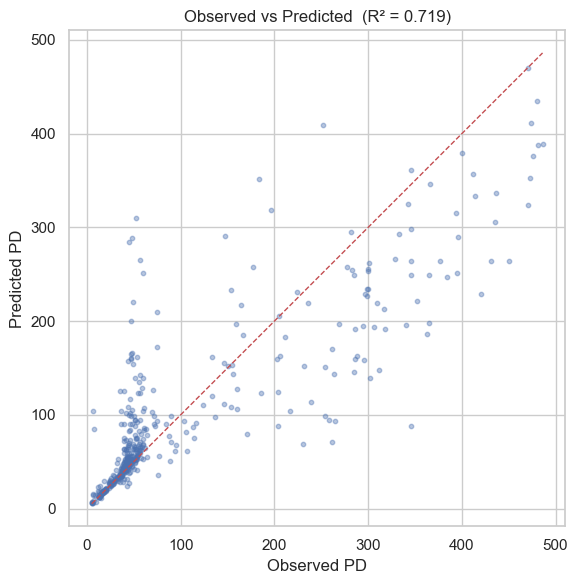

In [34]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=10, alpha=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Observed PD")
ax.set_ylabel("Predicted PD")
ax.set_title(f"Observed vs Predicted  (R² = {r2:.3f})")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

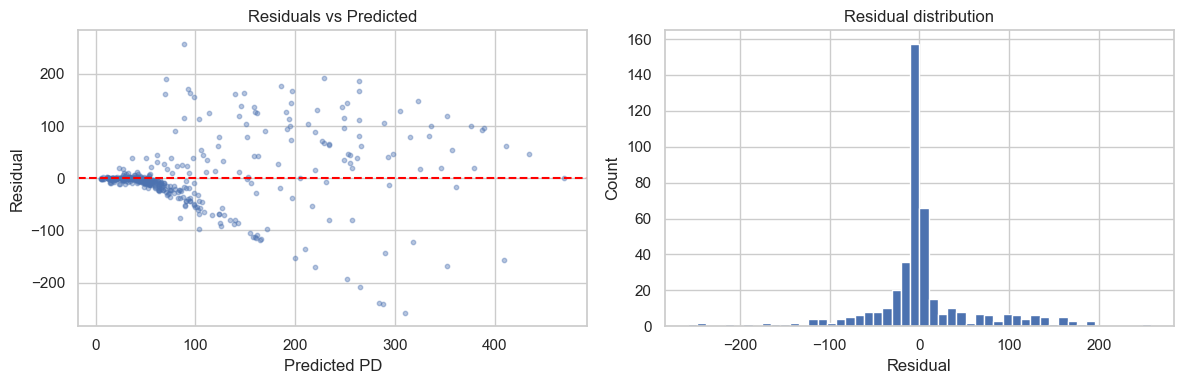

In [35]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, s=10, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted PD")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

### Feature importances van het gefitte Random Forest model

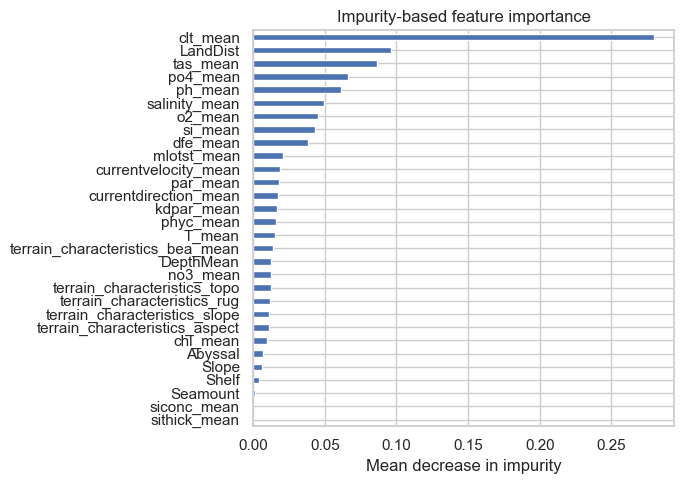

In [36]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity-based feature importance")
plt.tight_layout()
plt.show()

### Spatiale crossvalidatie

In [37]:
lat = df_merge.loc[df_model.index, "lat_deg"]
lon = df_merge.loc[df_model.index, "long_deg"]
lat_bin = pd.cut(lat, bins=np.arange(-90, 91, 10), labels=False)
lon_bin = pd.cut(lon, bins=np.arange(-180, 181, 10), labels=False)
spatial_blocks = lat_bin.astype(str) + "_" + lon_bin.astype(str)

print(f"\nSpatial blocks (10°×10° grid): {spatial_blocks.nunique()} unique blocks")

gkf = GroupKFold(n_splits=5)
spatial_cv = cross_val_score(
    rf, X, y, cv=gkf, groups=spatial_blocks, scoring="r2", n_jobs=-1,
)
print("Spatial  5-fold CV R² scores:", np.round(spatial_cv, 4))
print(f"Mean R²: {spatial_cv.mean():.4f}  ±  {spatial_cv.std():.4f}")


Spatial blocks (10°×10° grid): 422 unique blocks
Spatial  5-fold CV R² scores: [0.4749 0.6549 0.6455 0.6352 0.7354]
Mean R²: 0.6292  ±  0.0849


# Model met minder variabelen

Dimensionaliteit reduceren --> uitkijken voor bias

In [38]:
target_red = "PD" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols_red = df_merge.columns.drop(["long_deg", "lat_deg", "PD"]).tolist()

df_red = df_merge[[target_red] + feature_cols_red].copy()
print(f"Shape before cleaning: {df_red.shape}")
df_red.describe()

Shape before cleaning: (2452, 31)


,PD,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount,chl_mean,clt_mean,currentdirection_mean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
count,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2217.000000,2217.000000,2217.000000,...,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2217.000000
mean,97.907775,3395.364192,644.398042,106.702485,907.614120,1149.016243,0.092577,0.259398,0.447101,152.689401,...,0.059461,0.070197,14.698095,14.624145,183.500427,-3748.862966,94.427332,1.179893e+00,-2.727722,16.382824
std,115.578176,1807.135985,541.423334,418.417273,1081.733066,1189.317748,0.411971,0.215264,0.186835,80.485733,...,0.173575,0.215610,26.476457,11.465120,104.334155,1538.097895,106.862539,1.406274e+00,76.048905,10.565343
min,4.177602,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043151,0.027449,8.444567,...,0.000000,0.000000,0.656868,-16.241398,0.182399,-7138.611328,0.000000,2.484808e-17,-658.309052,-1.838033
25%,34.835263,2556.000000,204.000000,0.000000,0.000000,0.000000,0.000000,0.105136,0.271776,74.841409,...,0.000000,0.000000,1.594731,5.300397,93.788117,-4841.555664,30.402771,3.307500e-01,-28.128448,6.396754
50%,47.090843,3944.000000,525.500000,0.000000,135.741786,842.324758,0.000000,0.244400,0.450085,138.466769,...,0.000000,0.000000,2.670603,17.737980,184.875910,-4115.527832,62.715210,7.419182e-01,-1.149323,19.306662
75%,96.951054,4753.250000,987.250000,0.000000,1840.672129,2359.201000,0.000000,0.346993,0.613930,233.689689,...,0.000000,0.000000,13.881882,25.288107,274.005903,-3187.027832,117.663208,1.471722e+00,19.500183,26.387225
max,512.751559,7660.000000,2632.000000,3088.682000,3089.624000,3089.624000,8.000000,3.750575,0.785068,315.692114,...,0.963429,1.794409,121.972284,28.490869,359.858364,0.000000,1098.482654,1.466965e+01,748.565994,30.261832


Missende waarden verwijderen

In [39]:
df_red.replace(-9999.0, np.nan, inplace=True)
df_red.replace(-9999, np.nan, inplace=True)

missing = df_red.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_red.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_red.shape}")

Missende waarden per kolom:

chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean                             235
tas_mean                            235
terrain_characteristics_aspect      235
terrain_characteristics_bea_mean    235
terrain_characteristics_rug         235
terrain_characteristics_slope       235
terrain_characteristics_topo        235
T_mean                              235
dtype: int6

Nogmaals data-exploratie nodig?

In [40]:
X_red = df_red[feature_cols_red]
y_red = df_red[target_red]


## Recursive feature elimination 
### RMSE en spatiale cross validatie

In [41]:
print(X.isna().sum().sort_values(ascending=False).head(10))

DepthMean                0
LandDist                 0
Shelf                    0
Slope                    0
Abyssal                  0
Seamount                 0
chl_mean                 0
clt_mean                 0
currentdirection_mean    0
currentvelocity_mean     0
dtype: int64


In [ ]:
#from sklearn.feature_selection import RFECV

# Random Forest
#estimator = RandomForestRegressor(
    #n_estimators=500,
    #max_depth=20,
    #min_samples_leaf=10,
    #random_state=42,
    #n_jobs=-1
#)

# RFECV met spatial CV + RMSE
#selector = RFECV(
    #estimator,
    #step=1,
    #cv=gkf,
    #scoring="neg_root_mean_squared_error",
    #n_jobs=-1
#)

#selector.fit(X_red, y_red, groups=spatial_blocks)

#print(f"Optimal number of features: {selector.n_features_}")

#selected_features_RFECV = X.columns[selector.support_]
#print("Selected features:", list(selected_features_RFECV))

Optimal number of features: 23
Selected features: ['DepthMean', 'LandDist', 'Slope', 'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_bea_mean', 'terrain_characteristics_rug', 'terrain_characteristics_slope', 'T_mean']


In [48]:
selected_features_RFECV = [ # Dit zijn de variabelen die we hier selecteren om de biodiversiteit te voorspellen.
  "DepthMean",
  "LandDist",
  "Slope",
  "chl_mean",
  "clt_mean",
  "currentdirection_mean"
  "currentvelocity_mean",
  "dfe_mean",
  "kdpar_mean",
  "mlotst_mean",
  "no3_mean",
  "o2_mean", 
  "par_mean",
  "phyc_mean", 
  "ph_mean", 
  "po4_mean", 
  "salinity_mean", 
  "si_mean", 
  "tas_mean", 
  "terrain_characteristics_bea_mean",
  "terrain_characteristics_rug",
  "terrain_characteristics_slope",
  "T_mean"
]

### Data splitten in training en test set

In [43]:
X_selected = X[selected_features_RFECV]
y_selected = y

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y_selected, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train_selected.shape[0]}")
print(f"Test set: {X_test_selected.shape[0]}")

Training set: 1760
Test set: 441


# Fitten van een Random Forest model op training set met enkel geselecteerde features

In [44]:
rf_selected_RFECV = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_selected_RFECV.fit(X_selected, y_selected)

# Feature importances
imp = pd.Series(
    rf_selected_RFECV.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

Slope                               0.008590
terrain_characteristics_slope       0.012475
chl_mean                            0.013865
terrain_characteristics_rug         0.014051
kdpar_mean                          0.014850
no3_mean                            0.014862
terrain_characteristics_bea_mean    0.016633
DepthMean                           0.016880
currentvelocity_mean                0.017464
currentdirection_mean               0.017688
phyc_mean                           0.018083
mlotst_mean                         0.020343
par_mean                            0.020735
T_mean                              0.024067
dfe_mean                            0.031229
salinity_mean                       0.043048
tas_mean                            0.050827
ph_mean                             0.052569
si_mean                             0.053385
o2_mean                             0.056096
po4_mean                            0.061420
LandDist                            0.104129
clt_mean  

Hyperparameters optimaliseren

In [ ]:
#from sklearn.model_selection import GridSearchCV
#from sklearn.ensemble import RandomForestRegressor

#rf= RandomForestRegressor(random_state=42)

# de hyperparameters optimaliseren 
#param_grid = {
    #"n_estimators": [200, 500, 800],
    #"max_depth": [10, 20, 30, None],
    #"min_samples_leaf": [1, 5, 10],
    #"max_features": ["sqrt", 0.3, 0.5]
#}

#grid = GridSearchCV(
    #rf,
    #param_grid,
    #cv=5,
    #scoring="r2",
    #n_jobs=-1
#)

#grid.fit(X_train_selected, y_train_selected)

#print(grid.best_params_)

{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 500}


Deze hyperparameters gebruiken voor rf_selected_RFECV: max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 500

### Evalueren van rf op training en test set

Moet op beide goed zijn anders is het overgefit op training set

In [46]:
y_pred_sel = rf_selected_RFECV.predict(X_test_selected)

r2_train_sel = rf_selected_RFECV.score(X_train_selected, y_train_selected)
rmse_sel = np.sqrt(mean_squared_error(y_test_selected, y_pred_sel))
mae_sel = mean_absolute_error(y_test_selected, y_pred_sel)
r2_sel = r2_score(y_test_selected, y_pred_sel)

print(f"Train R²: {r2_train_sel:.4f}")
print(f"Test R²: {r2_sel:.4f}")
print(f"RMSE: {rmse_sel:.4f}")
print(f"MAE: {mae_sel:.4f}")
print(f"\nTrain-test gap: {r2_train_sel - r2_sel:.4f}")

Train R²: 0.9590
Test R²: 0.9652
RMSE: 21.6531
MAE: 11.8663

Train-test gap: -0.0062


Spatiale crossvalidatie nogmaals?

Toekomstige biodiversiteit voorspellen (SSP119, jaren 2050-2060)

In [47]:
toekomst = pd.read_csv(DATA_DIR / "PD_2050-60_SSP119.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Emma\\2. Bestanden\\1. UGent\\3e bachelor (2025-2026)\\2e semester\\Bachelorproef\\Programmeergedeelte\\Bachelorproef\\Data\\PD_2050-60_SSP119.csv'

In [ ]:
X_future = toekomst[X_train_selected.columns]

In [ ]:
PD_toekomst = rf_selected_RFECV.predict(X_future)

In [ ]:
toekomst["PD"] = PD_toekomst

In [ ]:
toekomst.head()

,Unnamed: 0,clt_mean,dfe_mean,mlotst_mean,o2_mean,phyc_mean,ph_mean,po4_mean,si_mean,salinity_mean,...,long_deg,lat_deg,DepthMean,LandDist,Slope,kdpar_mean,par_mean,terrain_characteristics_rug,terrain_characteristics_slope,SR
0,0,0.689485,0.000391,61.532763,314.002378,1.237505,7.970945,2.152274,0.729408,33.931405,...,-171.74579,-71.23536,3998,636,730.228795,0.060146,37.450932,66.347260,0.933108,37.940
1,1,0.700666,0.000376,63.236088,315.845510,1.337427,7.972867,2.166582,0.722381,33.946644,...,-167.88679,-71.23536,4079,742,0.000000,0.062998,29.998841,21.055542,0.320794,37.648
2,2,0.703526,0.000368,63.562959,315.316479,1.259565,7.973096,2.168482,0.690216,33.945152,...,-164.02779,-71.23536,4185,708,0.000000,0.072465,32.604841,14.489563,0.228825,40.278
3,3,0.697370,0.000348,59.205664,318.284476,1.335023,7.976109,2.159415,0.696709,33.912422,...,-160.16879,-71.23536,4231,661,0.000000,0.067391,31.006588,4.413208,0.081748,39.816
4,4,0.692536,0.000343,60.567262,317.223787,1.358980,7.975836,2.158386,0.697316,33.883653,...,-156.30979,-71.23536,4322,608,0.000000,0.066070,33.850906,10.302124,0.234018,39.612


Distributie van PD in de toekomst

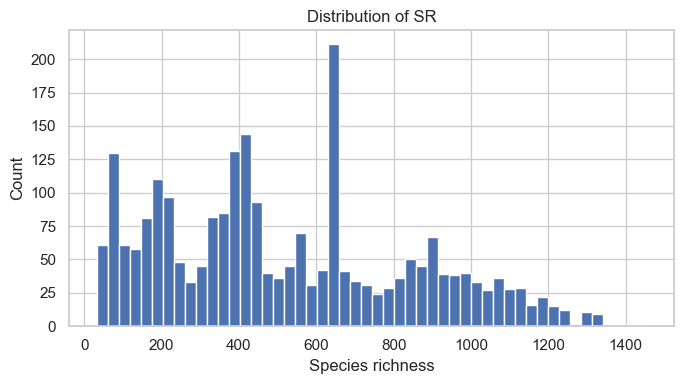

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(toekomst["PD"], bins=50, edgecolor="white")
ax.set_xlabel("Phylogenetic diversity")
ax.set_ylabel("Count")
ax.set_title("Distribution of PD")
plt.tight_layout()
plt.show()

Een kaartje maken om de biodiversiteit in de toekomst te visualiseren over de hele wereld

In [ ]:
import plotly.express as px
import plotly.io as pio

In [ ]:
fig = px.scatter_geo(
    toekomst,
    lat="lat_deg",
    lon="long_deg",
    color="PD",   # kleurt de punten op basis van biodiversiteit
    hover_name="PD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Phylogenetic diversity"
)
fig.show()